In [ ]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"

import jax
import jax.numpy as jnp
import numpy as np
import mujoco
import mediapy as media

from kandel.utility.checkpoint_loader import load_policy
from kandel.utility.checkpoint_loader import load_playground_environment
from kandel.utility import running_statistics

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

policy_forward_fcn = None

In [8]:
checkpoint_directory = "/home/alexanderdittrich/Downloads/xebec/250917015958-go1walkflatterrain-mlp-hebbian-openai-es-10/"
checkpoint = 599
policy_id = 0

policy, policy_params_init = load_policy(
    checkpoint_directory, checkpoint, policy_id
)
env, norm_state, cfg = load_playground_environment(
    checkpoint_directory, checkpoint
)

# Somehow this calls and error.
norm_state = norm_state.replace(count=0)

if policy_forward_fcn is None:
    # Vectorized environment functions
    env_reset_fcn = jax.jit(env.reset)
    env_step_fcn = jax.jit(env.step)

    # Vectorized environment and policy functions
    policy_forward_fcn = jax.jit(policy.forward)
    policy_update_fcn = jax.jit(policy.update)
    policy_reset_fcn = jax.jit(policy.reset)

    # Observation normalization
    obs_normalize_fcn = jax.jit(running_statistics.normalize)

sim_interval = cfg.simulation_interval
update_interval = cfg.update_interval

total_time = cfg.rollout_length * sim_interval
total_steps = int(total_time / min(sim_interval, update_interval))

sim_steps = cfg.rollout_length
update_steps = int(total_time / update_interval)

relative_sim_steps = int(total_steps / sim_steps)
relative_update_steps = int(total_steps / update_steps)

23.231728
23.465729
23.41791
23.369652
23.476788
23.354902
23.359858
23.462236


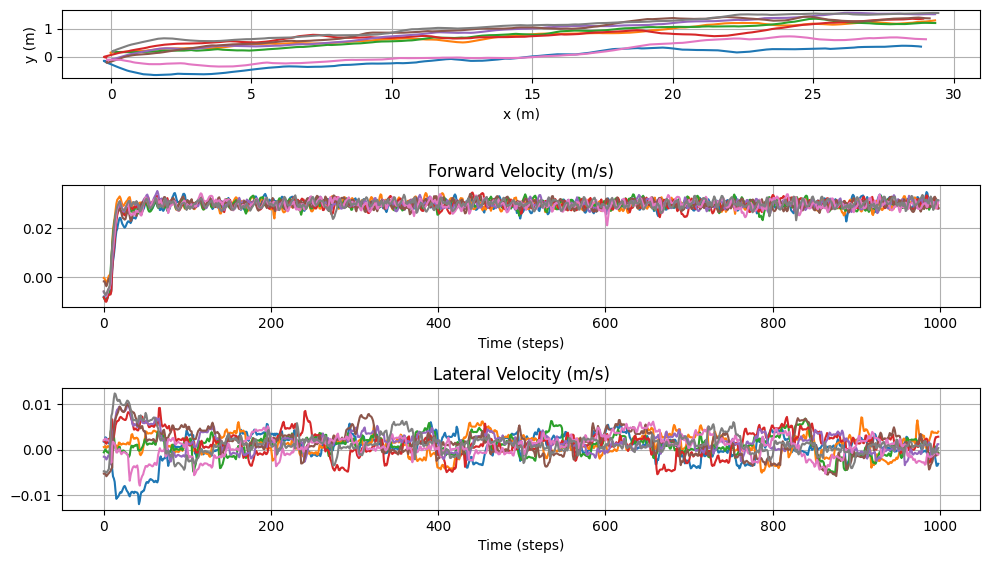

In [9]:
num_seeds = 8
episode_length = 1000

fig, axs = plt.subplots(3, 1, figsize=(10, 6))

for seed in range(num_seeds):
    key = jax.random.key(seed)
    env_state = env_reset_fcn(key)

    state_history = []
    action_history = []
    weight_history = [policy_params_init]

    policy_params = policy_params_init
    for t in range(episode_length):
        if t % relative_sim_steps == 0:
            obs = obs_normalize_fcn(env_state.obs, norm_state)
            policy_params, actions = policy_forward_fcn(policy_params, obs)
            actions = jnp.clip(
                actions, cfg.action_clip_min, cfg.action_clip_max
            )
            env_state = env_step_fcn(env_state, actions)

            # fill reward mask
            action_history.append(actions)
            state_history.append(env_state)

        if t % relative_update_steps == 0:
            policy_params = policy_update_fcn(policy_params)

        weight_history.append(policy_params)

    acc_rewards = jnp.array([env_state.reward for env_state in state_history])
    acc_rewards = jnp.sum(acc_rewards)
    print(acc_rewards)

    xposs = np.array([_state.data.xipos[1] for _state in state_history])

    axs[0].plot(xposs[:, 0], xposs[:, 1])
    axs[1].plot(np.diff(xposs[:, 0]))
    axs[2].plot(np.diff(xposs[:, 1]))

axs[0].set_xlabel("x (m)")
axs[0].set_ylabel("y (m)")
axs[0].set_aspect("equal")

axs[1].set_xlabel("Time (steps)")
axs[1].set_title("Forward Velocity (m/s)")
axs[2].set_xlabel("Time (steps)")
axs[2].set_title("Lateral Velocity (m/s)")

for ax in axs:
    ax.grid(True)

fig.tight_layout()
plt.show()

## Rendering

In [10]:
render_every = 1
fps = 1.0 / env.dt / render_every
traj = state_history[::render_every]

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = False

camera_names = [
    mujoco.mj_id2name(env.mj_model, mujoco.mjtObj.mjOBJ_CAMERA, i)
    for i in range(env.mj_model.ncam)
]
camera_names.append(0)
camera_names = [camera_names[0]]

for camera in camera_names:
    frames = env.render(
        traj, height=480, width=640, camera=camera, scene_option=scene_option
    )
    media.show_video(frames, fps=fps)

100%|██████████| 1000/1000 [00:01<00:00, 666.96it/s]


This browser does not support the video tag.


### Torques and Ground forces

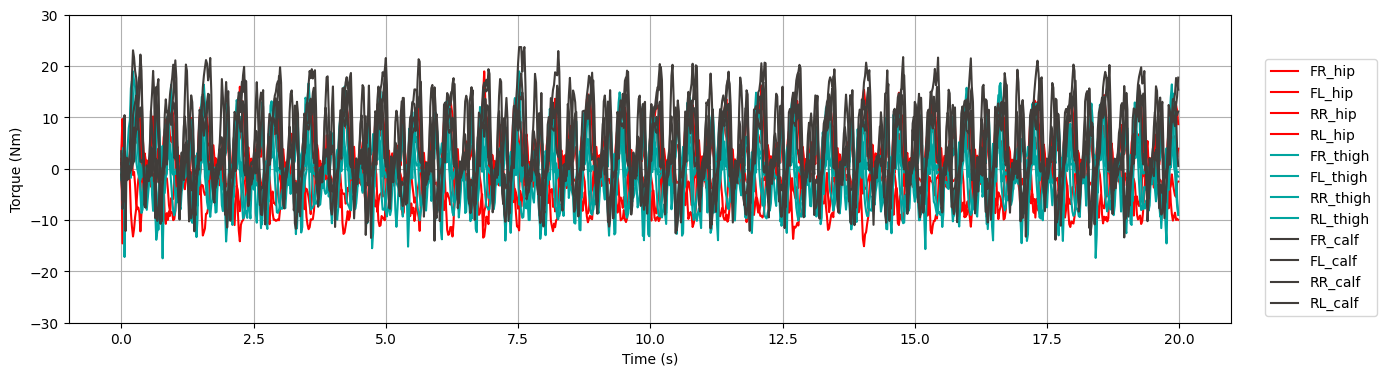

In [11]:
joint_names = [
    "FR_hip",  #
    "FR_thigh",
    "FR_calf",
    "FL_hip",
    "FL_thigh",
    "FL_calf",
    "RR_hip",
    "RR_thigh",
    "RR_calf",
    "RL_hip",
    "RL_thigh",
    "RL_calf",
]

# Extract torques
actuator_forces = []
for state in state_history:
    actuator_forces.append(state.data.actuator_force)
actuator_forces = np.array(actuator_forces)

# Generate plots
fig, ax = plt.subplots(figsize=(15, 4))
t = np.arange(len(actuator_forces)) * env.dt

ax.plot(
    t,
    actuator_forces[:, [0, 3, 6, 9]],
    label=[joint_names[i] for i in [0, 3, 6, 9]],
    c="#FF0000",
)
ax.plot(
    t,
    actuator_forces[:, [1, 4, 7, 10]],
    label=[joint_names[i] for i in [1, 4, 7, 10]],
    c="#00A49F",
)
ax.plot(
    t,
    actuator_forces[:, [2, 5, 8, 11]],
    label=[joint_names[i] for i in [2, 5, 8, 11]],
    c="#413D3A",
)

ax.grid(True)
ax.set_ylabel("Torque (Nm)")
ax.set_xlabel("Time (s)")
ax.set_ylim((-30, 30))

fig.legend(loc="outside center right")

plt.show()

## Weight dynamics

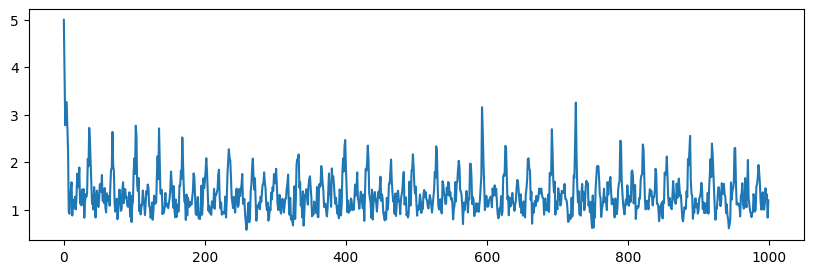

In [12]:
def compute_euclidian_distance(weight_history):
    euclidian_history = []
    layers = weight_history[0]["kernel_params"].keys()

    for t in range(len(weight_history) - 1):
        mse = 0.0
        for layer in layers:
            params_t1 = weight_history[t]["kernel_params"][layer]["W"]
            params_t2 = weight_history[t + 1]["kernel_params"][layer]["W"]
            mse += np.linalg.norm(params_t2 - params_t1)
        euclidian_history.append(mse)
    euclidian_history = np.array(euclidian_history)
    return euclidian_history


euclidian_history = compute_euclidian_distance(weight_history)
fig, axs = plt.subplots(figsize=(10, 3))
axs.plot(euclidian_history)

plt.show()

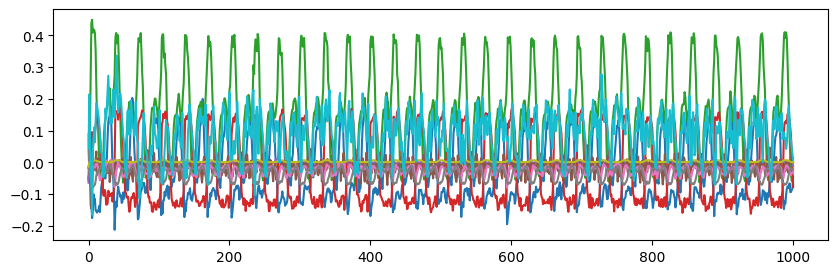

In [13]:
def select_random_weights(weight_history, num_neurons=10, selection_seed=0):
    np.random.seed(selection_seed)
    layers = weight_history[0]["kernel_params"].keys()

    indices = []
    for _ in range(num_neurons):
        selected_layer = np.random.choice(list(layers))
        array_shape = weight_history[0]["kernel_params"][selected_layer][
            "W"
        ].shape

        # Random indices
        ind_1 = np.random.randint(0, array_shape[0] - 1)
        ind_2 = np.random.randint(0, array_shape[1] - 1)

        indices.append((selected_layer, ind_1, ind_2))

    neuron_ts = []
    for i in indices:
        neuron_signal = []
        for t in range(len(weight_history)):
            neuron_signal.append(
                weight_history[t]["kernel_params"][i[0]]["W"][i[1], i[2]]
            )

        neuron_ts.append(neuron_signal)

    neuron_ts = np.array(neuron_ts)
    return neuron_ts


single_weight_history = select_random_weights(weight_history)

fig, axs = plt.subplots(figsize=(10, 3))
axs.plot(single_weight_history.T)

plt.show()

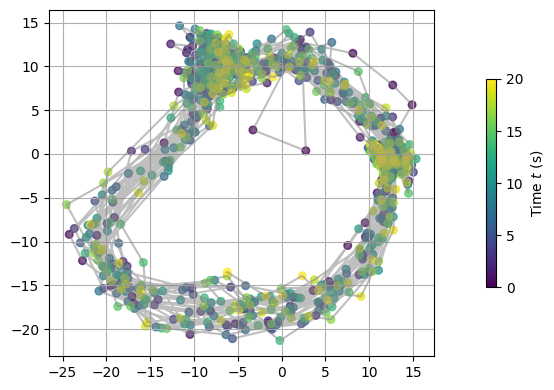

In [15]:
def compute_pca_2d(weight_history):
    pca = PCA(n_components=2)
    scaler = StandardScaler()

    flat_hist = []
    for t in range(len(weight_history)):
        params = weight_history[t]["kernel_params"]["layer_0"]["W"].flatten()
        flat_hist.append(params)

    flat_hist = np.array(flat_hist)
    flat_hist = scaler.fit_transform(flat_hist)
    weights_pca = pca.fit_transform(flat_hist)

    return weights_pca


pca_history = compute_pca_2d(weight_history)
t = np.arange(episode_length + 1) * env.dt

fig, axs = plt.subplots(figsize=(6.0, 4.0))
cmap = cm.viridis
norm = mcolors.Normalize(vmin=t[0], vmax=t[-1])

axs.plot(
    pca_history[:, 0],
    pca_history[:, 1],
    # pca_history[:, 2],
    color="grey",
    alpha=0.5,
)

axs.scatter(
    pca_history[:, 0],
    pca_history[:, 1],
    # pca_history[t, 2],
    alpha=0.7,
    c=t,
    cmap=cm.viridis,
    s=30,
)

axs.set_aspect("equal")

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# cbar = fig.colorbar(sm, ax=axs[2, -1])
# cbar.set_label("Time (s)", loc="top")

cbar = fig.colorbar(
    sm,
    ax=axs,
    # orientation="horizontal",
    fraction=0.02,
    pad=0.1,
    # aspect=80,
)
cbar.set_label(r"Time $t$ (s)")
axs.grid(True)
fig.tight_layout()
plt.show()